In [ ]:
!pip install scikeras
!pip install imblearn
!pip install xgboost
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from google.colab import files
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import AdaBoostClassifier
from scikeras.wrappers import KerasClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline



uploaded = files.upload()  # Upload your file in Colab

file_name = list(uploaded.keys())[0]  # Get the name of the uploaded file
data = pd.read_excel(file_name)


X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


scaler = StandardScaler()
X = scaler.fit_transform(X)


sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
for train_index, test_index in sss.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]


smote = SMOTE(k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


def build_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_resampled.shape[1],))) # Define input shape here
    model.add(Dense(32, activation='relu'))
    model.add(Dense(6, activation='softmax'))  # Output layer with 6 classes (softmax for probability)

    model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


nn_model = KerasClassifier(build_fn=build_model, epochs=500, batch_size=32, verbose=0)


# Create XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1)

# Stack models together with a logistic regression meta-learner
stacking_model = StackingClassifier(
    estimators=[('xgb', xgb_model), ('nn', nn_model)],
    final_estimator=LogisticRegression()
)

# Define parameter grids for hyperparameter tuning
#param_grid = {
    #'stackingclassifier__xgb__n_estimators': [50, 100, 200],
    #'stackingclassifier__xgb__learning_rate': [0.01, 0.1, 0.2],
    #'stackingclassifier__xgb__max_depth': [3, 5, 7],
    #'stackingclassifier__nn__epochs': [100, 200, 300],
    #'stackingclassifier__nn__batch_size': [16, 32, 64],
    #'stackingclassifier__final_estimator__C': [0.1, 1.0, 10.0]
#
param_grid = {
    'stackingclassifier__xgb__n_estimators': [100],
    'stackingclassifier__xgb__learning_rate': [0.1],
    'stackingclassifier__xgb__max_depth': [5],
    'stackingclassifier__nn__epochs': [200],
    'stackingclassifier__nn__batch_size': [32],
    'stackingclassifier__final_estimator__C': [1.0]
}

# Wrap the stacking model in a pipeline
pipeline = Pipeline([
    ('stackingclassifier', stacking_model)
])

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,  # Number of parameter settings sampled
    scoring='accuracy',  # Scoring metric
    cv=3,  # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available processors
)

# Train the stacking model
random_search.fit(X_resampled, y_resampled)

# Print the parameters of the best model
print("Best parameters found by RandomizedSearchCV:")
print(random_search.best_params_)


Saving 594_bowel_management.xlsx to 594_bowel_management.xlsx
Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error 

Best parameters found by RandomizedSearchCV:
{'stackingclassifier__xgb__n_estimators': 100, 'stackingclassifier__xgb__max_depth': 5, 'stackingclassifier__xgb__learning_rate': 0.1, 'stackingclassifier__nn__epochs': 200, 'stackingclassifier__nn__batch_size': 32, 'stackingclassifier__final_estimator__C': 1.0}


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


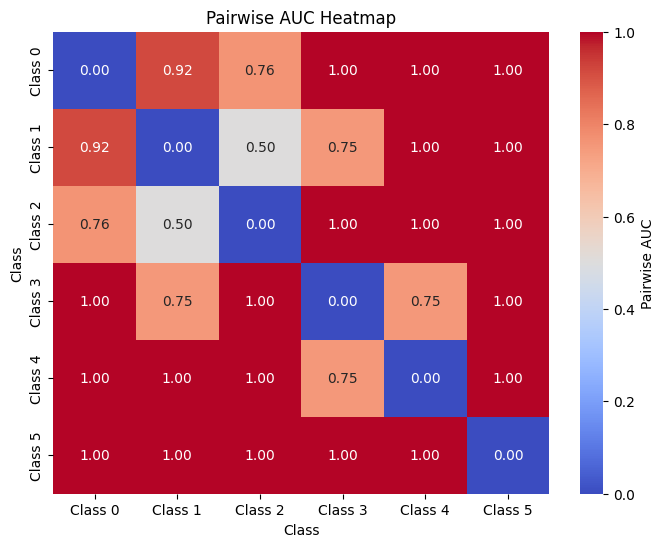

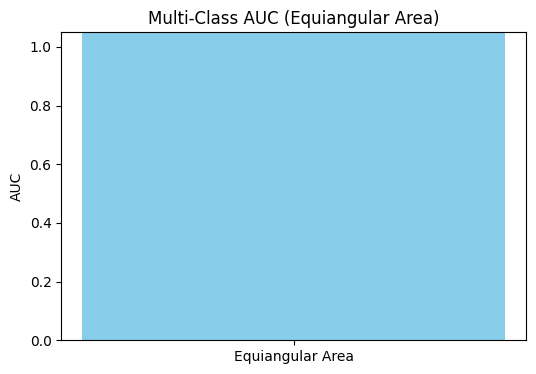

Accuracy: 0.8611
Macro AUC Score: 1.0000
Macro Precision: 0.8206
Macro Recall: 0.8611
Macro F1 Score: 0.8390
Multi-Class AUC (equiangular area): 2.536725826366754


PermutationExplainer explainer: 37it [01:17,  2.42s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

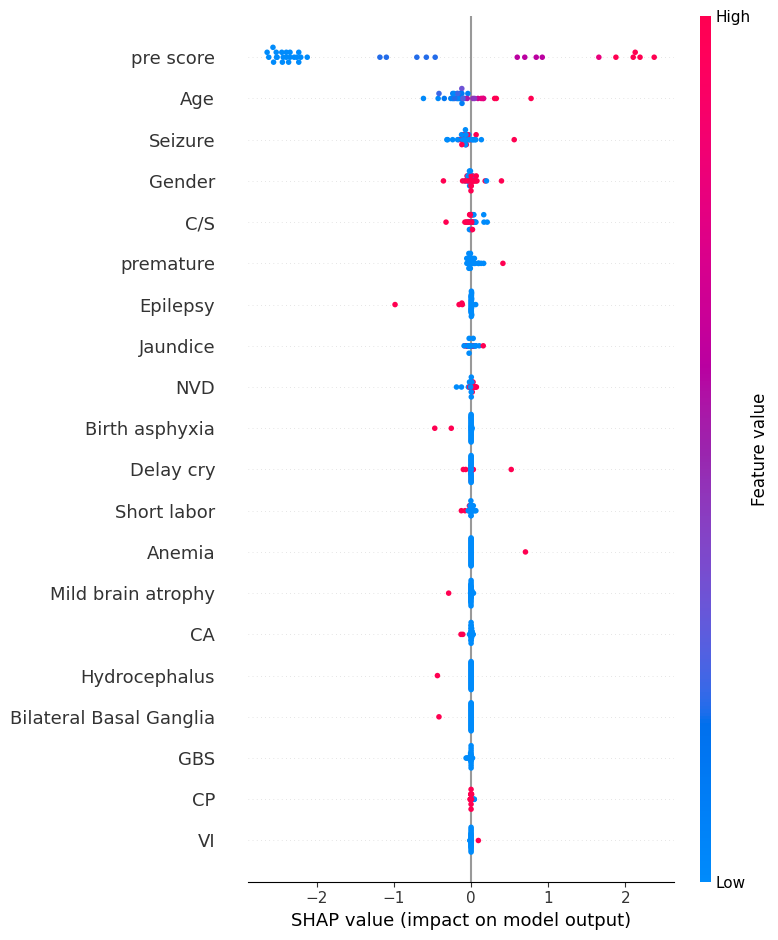

In [ ]:
from sklearn.metrics import roc_auc_score
from itertools import combinations
import math
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Predict probabilities for the test set
y_pred_proba = random_search.predict_proba(X_test)
n_classes = 6


# Make predictions
y_pred = random_search.predict(X_test)
y_test_binarized = label_binarize(y_test, classes=range(len(set(y))))
y_pred_binarized = label_binarize(y_pred, classes=range(len(set(y))))
# Precision, Recall, F1-Score, and AUC Score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
auc = roc_auc_score(y_test_binarized, random_search.predict_proba(X_test), average='weighted', multi_class='ovr')


# Step 2: Binarize the labels for multi-class AUC computation
y_test_binarized = label_binarize(y_test, classes=list(range(6)))

# Step 3: Calculate pairwise AUCs
pairwise_aucs = []
class_pairs = list(combinations(range(6), 2))  # Generate all class pairs (C(6, 2) = 15)
pairwise_auc_matrix = np.zeros((n_classes, n_classes))


for class_a, class_b in class_pairs:
    # Filter probabilities and true labels for the two classes
    mask = (y_test == class_a) | (y_test == class_b)
    y_true_pair = y_test[mask]
    # Use boolean indexing for rows and integer indexing for columns separately
    y_proba_pair = y_pred_proba[mask][:, [class_a, class_b]]  # Keep only the columns for class_a and class_b

    # Re-label for binary classification
    y_true_binary = (y_true_pair == class_b).astype(int)  # 1 for class_b, 0 for class_a

    # Calculate AUC for the pair
    auc = roc_auc_score(y_true_binary, y_proba_pair[:, 1])  # Use probabilities for class_b
    pairwise_aucs.append(auc)
    pairwise_auc_matrix[class_a, class_b] = auc
    pairwise_auc_matrix[class_b, class_a] = auc

# Step 2: Plot Pairwise AUC Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pairwise_auc_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            xticklabels=[f"Class {i}" for i in range(n_classes)],
            yticklabels=[f"Class {i}" for i in range(n_classes)],
            cbar_kws={'label': 'Pairwise AUC'})
plt.title('Pairwise AUC Heatmap')
plt.xlabel('Class')
plt.ylabel('Class')
plt.show()

# Step 4: Compute the multi-class AUC using the equiangular area approach
q = len(pairwise_aucs)  # Number of pairwise AUCs (should be 15)
r = np.mean(pairwise_aucs)  # Mean pairwise AUC, used for normalization

# Maximum area calculation (equiangular polygon)
equiangular_area = (q / 2) * (r ** 2) * math.sin((2 * math.pi) / q)


plt.figure(figsize=(6, 4))
plt.bar(["Equiangular Area"], [equiangular_area], color='skyblue')
plt.title('Multi-Class AUC (Equiangular Area)')
plt.ylabel('AUC')
plt.ylim(0, 1.05)  # Assuming AUC is between 0 and 1
plt.show()

# Step 5: Print results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro AUC Score: {auc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print("Multi-Class AUC (equiangular area):", equiangular_area)

# Use SHAP to explain the stacking model predictions
# Wrap the stacking_model.predict function to make it callable
explainer = shap.Explainer(random_search.predict, X_resampled)  # SHAP Explainer
shap_values = explainer(X_test)

plt.figure()  # Create a new figure
shap.summary_plot(shap_values, X_test, feature_names=data.columns[:-1], show=False)

x_min, x_max = -1, 1  # Adjust based on desired range
plt.xlim(x_min, x_max)

# Save the plot as a PNG file
output_file = "shap_summary_plot.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.close()  # Close the plot to free resources

files.download(output_file)

# Visualize feature importances for multi-class classification
shap.summary_plot(shap_values, X_test, feature_names=data.columns[:-1])
